# Problem Statement:

The goal of this project is to build a supervised classification model that predicts whether a candidate will be admitted to a graduate program based on their GMAT score, undergraduate GPA, and years of work experience.

Using historical data of past applicants including their admission outcomes the model will learn patterns that distinguish admitted candidates from those who were not admitted. This model can help admission committees identify strong candidates efficiently and support data-driven decision-making in the admissions process.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler


In [5]:
# Load the data
data = pd.read_csv('./Data.csv')

data.head(20)

,gmat,gpa,work_experience,admitted
0,780,4.0,3,yes
1,750,3.9,4,yes
2,690,3.3,3,no
3,710,3.7,5,yes
4,680,3.9,4,no
5,730,3.7,6,yes
6,690,2.3,1,no
7,720,3.3,4,yes
8,740,3.3,5,yes
9,690,1.7,1,no


In [6]:
# Step 2
data["admitted"] = data["admitted"].map({"yes": 1, "no": 0})

data.head(10)

,gmat,gpa,work_experience,admitted
0,780,4.0,3,1
1,750,3.9,4,1
2,690,3.3,3,0
3,710,3.7,5,1
4,680,3.9,4,0
5,730,3.7,6,1
6,690,2.3,1,0
7,720,3.3,4,1
8,740,3.3,5,1
9,690,1.7,1,0


# Building the model

In [7]:
# x = data.drop('admitted', axis=1)
# y = data['admitted']

x = data[['gmat', 'gpa', 'work_experience']]
y = data['admitted']

In [8]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state =42, stratify=y)

In [9]:
# Build and train a logistic regression model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [10]:
# Make some predictions and assess how our model performs
training_predictions = logreg.predict(x_train)
testing_predictions = logreg.predict(x_test)

# print the results of the training and the testing predictions
print("Training predictions", training_predictions)
print("Testing predictions", testing_predictions)

Training predictions [1 0 0 1 0 1 1 0 0 1 0 1 1 0 0 0 0 1 0 1 0 1 1 1 0 1 1 1 1 0 1 0]
Testing predictions [0 0 1 1 0 1 0 1]


In [11]:
# Check the models accuracy score for the training predictions
print("Training accuracy score", accuracy_score(y_train, training_predictions))

Training accuracy score 0.875


In [12]:
# check the model accuray for the testing predictions
print("Testing accuracy score", accuracy_score(y_test, testing_predictions))

Testing accuracy score 1.0


In [13]:
# print a classification report
print(classification_report(y_test, testing_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



In [14]:
import plotly.express as px
fig = px.scatter(data, x='gmat', y='admitted').add_scatter(x=np.linspace(data['gmat'].min(), data['gmat'].max(), 100), y=LogisticRegression().fit(data[['gmat']], data['admitted']).predict_proba(np.linspace(data['gmat'].min(), data['gmat'].max(), 100).reshape(-1, 1))[:, 1], mode='lines')
fig.show()

c:\Users\geoff\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



# Building a KNN model

In [15]:
# Step1
# Scale the features
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),                # Step 1: scale features
    ("knn", KNeighborsClassifier(n_neighbors=5))  # Step 2: KNN classifier (start with K=5)
])

In [16]:
# Step 2
knn_pipeline.fit(x_train, y_train)
y_pred_knn = knn_pipeline.predict(x_test)

# show a few prediction the model made
y_pred_knn[: 10]

array([0, 0, 1, 1, 0, 1, 0, 1], dtype=int64)

In [17]:
# Evaluate the KNN model with accuracy and a classification report
knn_test_accutracy = accuracy_score(y_test, y_pred_knn)
print("KNN Test Accuracy:", knn_test_accutracy)

print(classification_report(y_test, y_pred_knn))


KNN Test Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



# Finding the optimal K for KNN

In [18]:
# Imoprt GirdsearchCV
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Create a list of K VALUES  to test which one worsk best for KNN
# Max n_neighbors should be less than or equal to (min_samples_per_fold - 1)
# min_samples_per_fold = (len(x_train) * (cv.n_splits - 1) / cv.n_splits) which is (32 * 4/5) = 25.6
# So, max n_neighbors should be 25.
para_gid = {
    "knn__n_neighbors": list(range(1, 26, 2))  # 1 to 25, odd numbers only
}

# Setting up a testing rule: Split the data into 5 equal parts while keeping
# the balance of yes/no outcomes the same in each part
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create a seach engine that will run the model mutiple times using every setting
# on our list to see which one is the most accurate
grid_search = GridSearchCV(estimator = knn_pipeline, param_grid=para_gid, cv=cv, scoring = "accuracy")

# Start the process of running all those tests on your training data
grid_search.fit(x_train, y_train)

# Show the winning K value
print("Best K value:", grid_search.best_params_['knn__n_neighbors'])

# Show the highest accuracy score achieved during the testing process
print("Best accuracy score:", grid_search.best_score_)

Best K value: 5
Best accuracy score: 0.8857142857142858


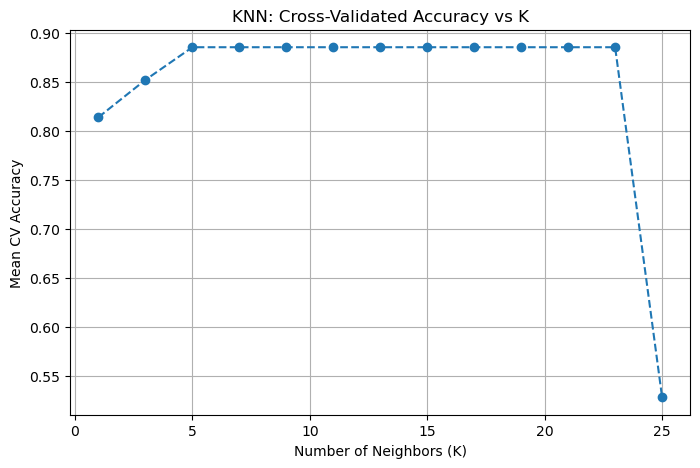

In [19]:
# Plot cross-validated accuracy vs K (this is the "accuracy curve" for KNN)
results = pd.DataFrame(grid_search.cv_results_)
results["K"] = results["param_knn__n_neighbors"].astype(int)

plt.figure(figsize=(8, 5))
plt.plot(results["K"], results["mean_test_score"], marker="o", linestyle="--")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean CV Accuracy")
plt.title("KNN: Cross-Validated Accuracy vs K")
plt.grid(True)
plt.show()